In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


## Story 1: Sales Trends & Seasonality

The business question:

"How has Olist's revenue and order volume changed over time — and are there patterns by month, day, or hour that the business should act on?"

Step 1 — Which tables do we need?

We have 9 datasets. For a sales trend analysis, we only need 2 of them:

orders — has the purchase timestamp (the when)
order_items — has price and freight value (the how much)
We join them on order_id.

Step 2 — Which columns specifically?

From orders:

order_id — to join
order_purchase_timestamp — the moment a customer placed the order
order_status — we'll filter to only delivered orders (cancelled/unavailable orders shouldn't count as revenue)

From order_items:

order_id — to join
price — product price
freight_value — shipping cost

Revenue = price + freight_value (what the customer actually paid)

In [2]:
## imports & loading data

import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
items  = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## Filter to delivered orders only

In [5]:
# filter to delivered orders only

# See all unique status values first
print(orders['order_status'].value_counts())

# Keep only delivered orders
orders = orders[orders['order_status'] == 'delivered']

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Why filter? Cancelled, invoiced, or processing orders never generated real revenue. Including them would inflate or distort your sales numbers. Always understand what each status means before plotting.

## Parse the timestamp (critical step)

In [6]:
# Convert from string → datetime so pandas understands it as a date
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

# Extract useful time parts as new columns
orders['year']       = orders['order_purchase_timestamp'].dt.year
orders['month']      = orders['order_purchase_timestamp'].dt.month
orders['month_name'] = orders['order_purchase_timestamp'].dt.strftime('%b')
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour']       = orders['order_purchase_timestamp'].dt.hour
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

Why parse timestamps? When loaded from CSV, dates are plain strings — pandas can't do "group by month" on a string. pd.to_datetime() converts it into a real datetime object. The .dt accessor then lets you pull out year, month, hour etc. as separate columns — these become your groupby keys for all trend charts.

## Join the two tables & calculate revenue

In [7]:
# Join orders + items on order_id
df = orders.merge(items[['order_id', 'price', 'freight_value']],
                  on='order_id', how='left')

# Revenue = what the customer actually paid
df['revenue'] = df['price'] + df['freight_value']

Why left join? We start from orders (left) and bring in item prices. how='left' keeps all orders even if an item row is missing — you'd rather see a null than silently lose an order. Also note we only select 3 columns from items — don't merge full tables when you only need a few columns.

## Monthly revenue trend (the headline chart)

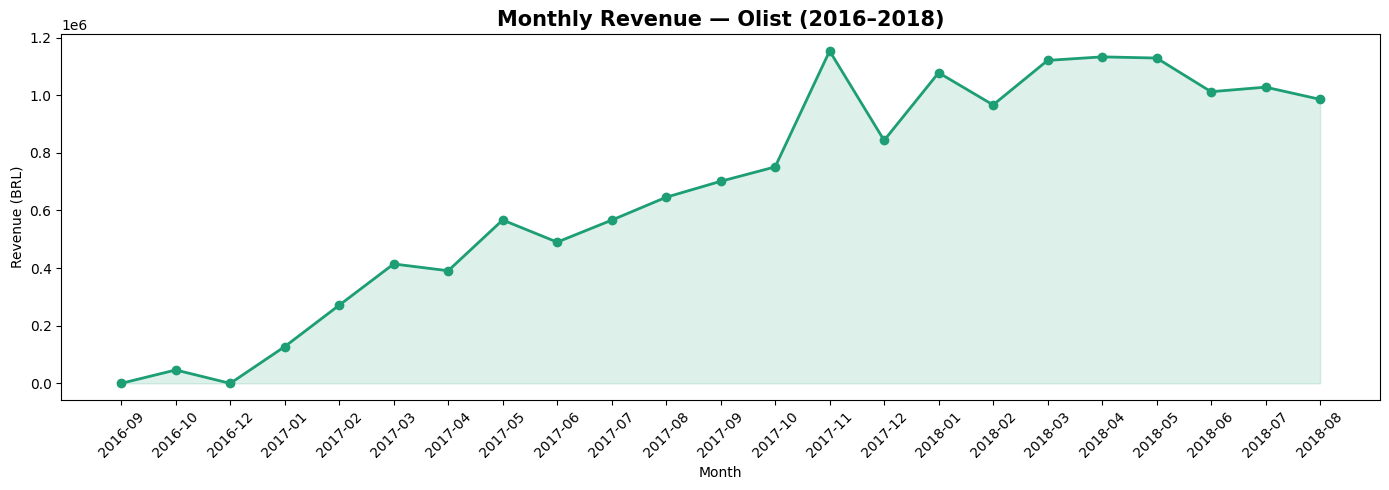

In [8]:
# Aggregate: total revenue per month
monthly_revenue = (
    df.groupby('year_month')['revenue']
      .sum()
      .reset_index()
)
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype('str')

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_revenue['year_month'],
        monthly_revenue['revenue'],
        marker='o', linewidth=2, color='#1D9E75')
ax.fill_between(monthly_revenue['year_month'],
                monthly_revenue['revenue'], alpha=0.15, color='#1D9E75')

# Annotations — this is what makes it a story, not just a chart
ax.set_title('Monthly Revenue — Olist (2016–2018)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Why fill_between? The shaded area under the line makes the growth story visually obvious — a plain line chart is harder to read at a glance. Always add a title, axis labels, and rotate x-axis ticks when you have many date labels. A chart without labels is not a story, it's just a shape.

## Order volume by day of week

/tmp/ipykernel_58/2407374672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_counts, x='day', y='order_count', palette='Blues_d')


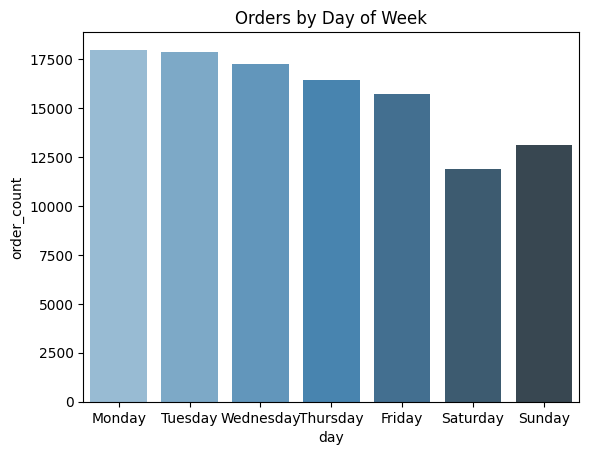

In [9]:
# Order the days correctly (not alphabetical)
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

day_counts = (
    df.groupby('day_of_week')['order_id']
      .count()
      .reindex(day_order)
      .reset_index()
)
day_counts.columns = ['day', 'order_count']

sns.barplot(data=day_counts, x='day', y='order_count', palette='Blues_d')
plt.title('Orders by Day of Week')
plt.show()

"Order volume is highest at the start of the week (Monday–Tuesday) and drops toward the weekend, suggesting weekly promotions should launch on Sunday night to capture early-week buying intent."

Why reindex? Without it, pandas sorts days alphabetically — Friday, Monday, Saturday... which is meaningless. Always enforce a logical order on categorical data before plotting. This is a very common beginner mistake.

## Order volume by hour of day

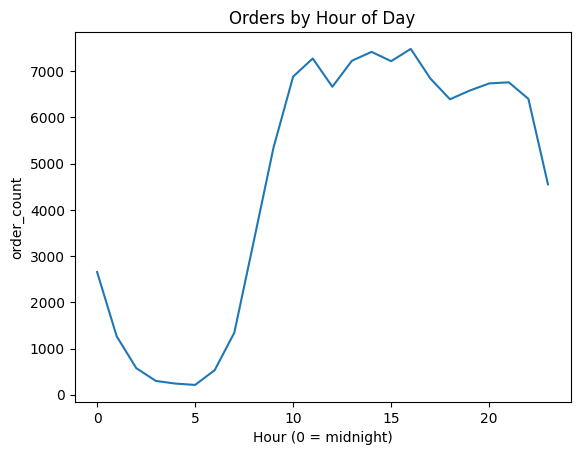

In [10]:
hourly = df.groupby('hour')['order_id'].count().reset_index()
hourly.columns = ['hour', 'order_count']

sns.lineplot(data=hourly, x='hour', y='order_count')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour (0 = midnight)')
plt.show()

"Peak ordering hours are between 10am–4pm, suggesting marketing emails and flash sale notifications should be scheduled in the morning so they land in customers' inboxes right before the peak window begins."

Why hourly? This tells you when in the day customers are most active — useful for timing marketing emails or flash sales. You'll likely see a peak around 10am–2pm. That's a business insight.

Revenue is very low in late 2016, grows steadily through 2017, then spikes sharply in November 2017, dips in December, then continues growing in 2018.


## Hypothesis 1 — It's Black Friday (last Friday of November)

In [11]:

# Filter to just November 2017
nov_2017 = df[
    (df['order_purchase_timestamp'].dt.year == 2017) &
    (df['order_purchase_timestamp'].dt.month == 11)
]

# Plot daily order count within November
daily = nov_2017.groupby(
    nov_2017['order_purchase_timestamp'].dt.day
)['order_id'].count()

print(daily)
# If you see a massive spike on day 24 (Black Friday 2017) → confirmed

order_purchase_timestamp
1      126
2      141
3      169
4      129
5      158
6      201
7      174
8      194
9      216
10     183
11     168
12     184
13     228
14     212
15     207
16     249
17     221
18     166
19     175
20     253
21     254
22     231
23     326
24    1345
25     569
26     450
27     469
28     427
29     359
30     291
Name: order_id, dtype: int64


## Hypothesis 2 — It's a broader month effect, not one day

In [12]:
# Compare average daily orders across all months
df['date'] = df['order_purchase_timestamp'].dt.date
daily_all = df.groupby('date')['order_id'].count()
print(daily_all.sort_values(ascending=False).head(10))
# If Nov 24 appears at the top → Black Friday confirmed
# If the top 10 are spread across November → broader seasonal effect

date
2017-11-24    1345
2017-11-25     569
2017-11-27     469
2017-11-26     450
2017-11-28     427
2018-08-06     421
2018-05-15     419
2018-08-07     417
2018-05-07     409
2018-05-14     404
Name: order_id, dtype: int64


## Story 2 — Delivery Performance

"Are orders reaching customers on time — and which states are causing the most delays?

In [15]:
## Step A — load & filter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the 3 tables we need 

orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

In [16]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
orders = orders[orders['order_status'] == 'delivered']

Why only delivered? Only delivered orders have a real order_delivered_customer_date. All other statuses have NaT (empty) in that column — subtracting NaT gives NaT, not a number. Filtering first avoids messy null results.

In [18]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [22]:
## to check the filter worked
orders['order_status'].value_counts()

order_status
delivered    96478
Name: count, dtype: int64

In [26]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [27]:
## Step B — parse date columns

# Convert all 3 date columns from string to datetime

date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

Why parse all 3? We need to subtract dates from each other. Python can only subtract datetime objects, not strings. Always parse every date column before doing any date math.

In [28]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [29]:
## Step C — feature engineering

# delivery_delay: positive = late, negative = early
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# actual_delivery_days: how long did the customer actually wait?
orders['actual_delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

# is_late: simple True/False flag
orders['is_late'] = orders['delivery_delay'] > 0

# Sanity check — always do this after feature engineering
print(orders[['delivery_delay',
              'actual_delivery_days',
              'is_late']].describe())

       delivery_delay  actual_delivery_days
count    96470.000000          96470.000000
mean       -11.875889             12.093604
std         10.182105              9.551380
min       -147.000000              0.000000
25%        -17.000000              6.000000
50%        -12.000000             10.000000
75%         -7.000000             15.000000
max        188.000000            209.000000


Why .dt.days? Subtracting two datetime columns gives a Timedelta — "3 days 00:00:00". We want a plain integer (3) for plotting and math. .dt.days extracts just the number. Also notice actual_delivery_days tells us total wait time from purchase — a different and equally useful metric.

Late order rate: 6.8%


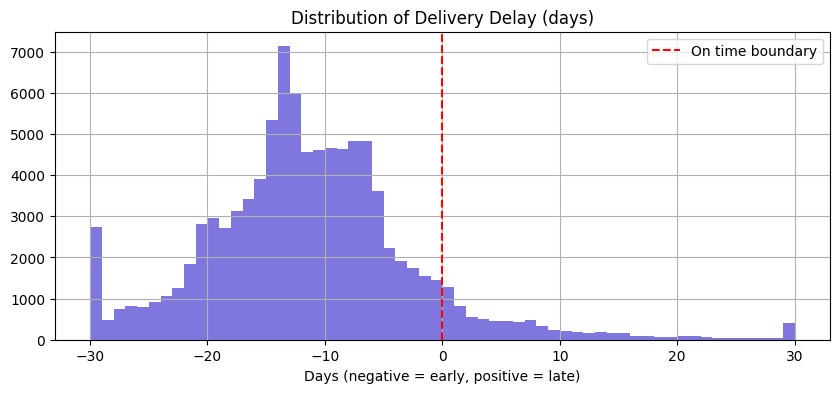

In [30]:
## Step D — overall late order rate

# What % of orders were late overall?
late_rate = orders['is_late'].mean() * 100
print(f"Late order rate: {late_rate:.1f}%")

# Distribution of delivery delay
fig, ax = plt.subplots(figsize=(10, 4))
orders['delivery_delay'].clip(-30, 30).hist(
    bins=60, color='#7F77DD', ax=ax)
ax.axvline(x=0, color='red',
           linestyle='--', label='On time boundary')
ax.set_title('Distribution of Delivery Delay (days)')
ax.set_xlabel('Days (negative = early, positive = late)')
plt.legend()
plt.show()

Why .clip(-30, 30)? Extreme outliers (200+ day delays) would squash the chart making the main distribution invisible. Clipping limits the x-axis to where 95% of data lives. The red line at 0 makes the late/early boundary instantly visible — that's storytelling, not just plotting.

In [32]:
df = orders.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id', how='left')

print(df['delivery_delay'].quantile(0.01))
print(df['delivery_delay'].quantile(0.99))

-36.0
18.0


<Axes: >

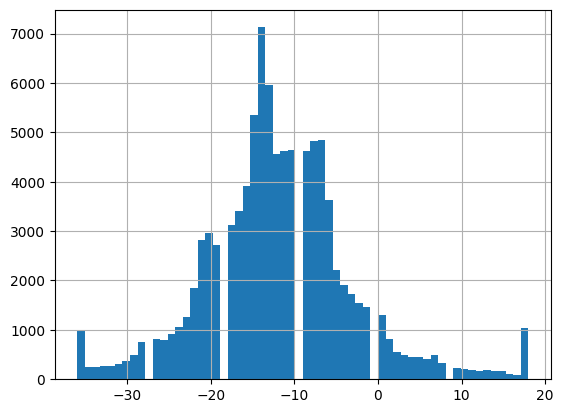

In [33]:
# Data-driven clipping
low  = df['delivery_delay'].quantile(0.01)
high = df['delivery_delay'].quantile(0.99)

df['delivery_delay'].clip(low, high).hist(bins=60)

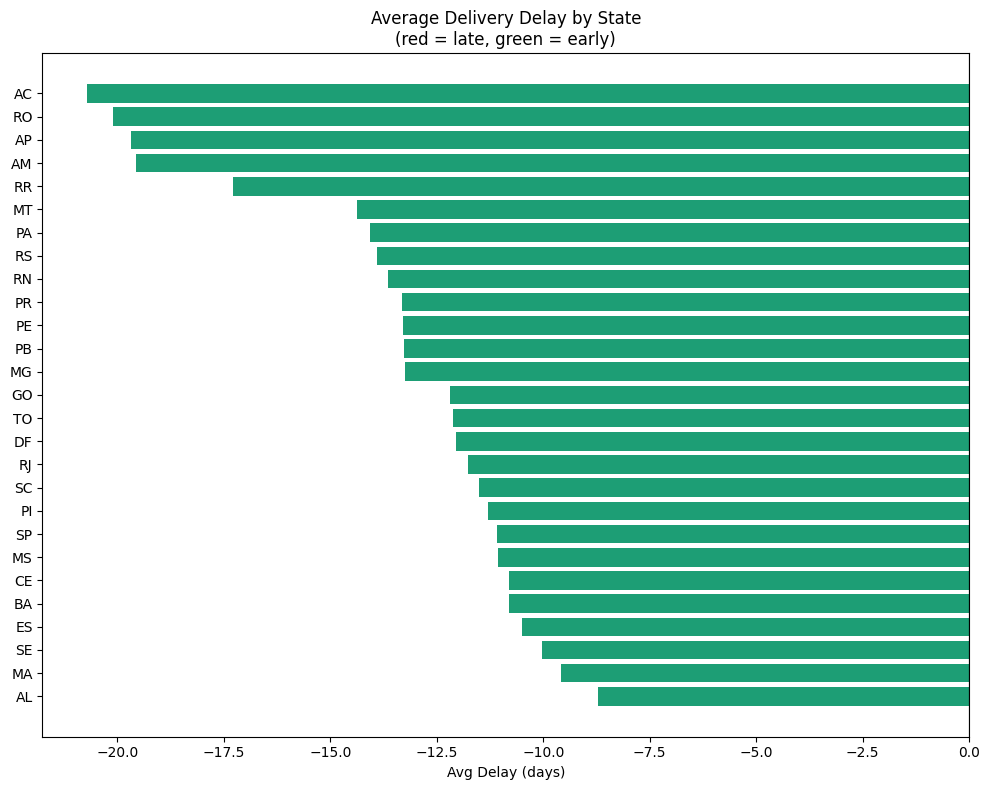

In [35]:
## Step E — delay by customer state

state_delay = (
    df.groupby('customer_state')['delivery_delay']
      .mean()
      .sort_values(ascending = False)
      .reset_index()
)

# Red = late, green = early — story visible at a glance
colors = ['#D85A30' if x > 0 else '#1D9E75'
          for x in state_delay['delivery_delay']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(state_delay['customer_state'],
        state_delay['delivery_delay'],
        color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Average Delivery Delay by State\n(red = late, green = early)')
ax.set_xlabel('Avg Delay (days)')
plt.tight_layout()
plt.show()

In [36]:
state_delay['delivery_delay']

0     -8.707809
1     -9.571827
2    -10.020896
3    -10.496241
4    -10.794533
5    -10.804535
6    -11.052782
7    -11.075542
8    -11.306723
9    -11.503384
10   -11.761215
11   -12.048077
12   -12.131387
13   -12.185488
14   -13.242998
15   -13.261122
16   -13.293785
17   -13.314239
18   -13.649789
19   -13.910367
20   -14.066596
21   -14.363431
22   -17.292683
23   -19.565517
24   -19.686567
25   -20.102881
26   -20.725000
Name: delivery_delay, dtype: float64

As we only see green bar, it would be a good instinct to investigate the graph a bit to make sure the data represented is correct

In [38]:
## Step 1 — Check your state_delay values first:

print(state_delay)

   customer_state  delivery_delay
0              AL       -8.707809
1              MA       -9.571827
2              SE      -10.020896
3              ES      -10.496241
4              BA      -10.794533
5              CE      -10.804535
6              MS      -11.052782
7              SP      -11.075542
8              PI      -11.306723
9              SC      -11.503384
10             RJ      -11.761215
11             DF      -12.048077
12             TO      -12.131387
13             GO      -12.185488
14             MG      -13.242998
15             PB      -13.261122
16             PE      -13.293785
17             PR      -13.314239
18             RN      -13.649789
19             RS      -13.910367
20             PA      -14.066596
21             MT      -14.363431
22             RR      -17.292683
23             AM      -19.565517
24             AP      -19.686567
25             RO      -20.102881
26             AC      -20.725000


as we can see all values are negative. All bars will be green because your condition if x > 0 is never True.

In [39]:
## Step 2 — Also check this:

print(state_delay['delivery_delay'].max())

## If this is still negative — no state has a positive average delay, meaning Olist delivers early in every state on average.

-8.707808564231739


"Despite individual late orders, no state has a positive average delivery delay — Olist consistently beats its own estimates across all 27 states."

In [37]:
print(df['customer_state'].value_counts())
print(df['customer_state'].isna().sum())

customer_state
SP    40501
RJ    12350
MG    11354
RS     5345
PR     4923
SC     3546
BA     3256
DF     2080
ES     1995
GO     1957
PE     1593
CE     1279
PA      946
MT      886
MA      717
MS      701
PB      517
PI      476
RN      474
AL      397
SE      335
TO      274
RO      243
AM      145
AC       80
AP       67
RR       41
Name: count, dtype: int64
0


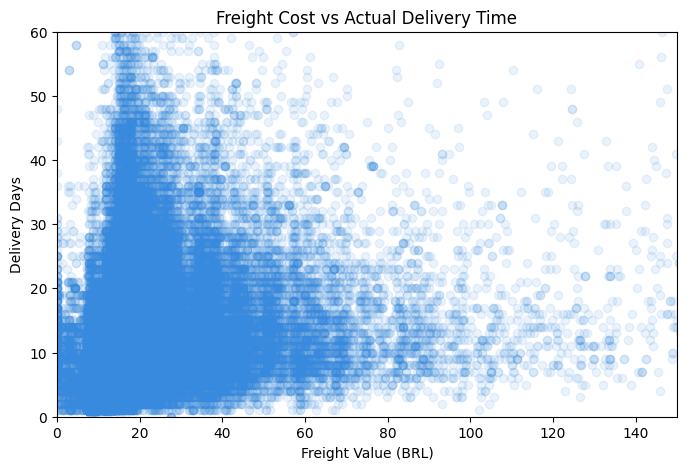

In [40]:
## Step F — freight cost vs delivery time

# Does paying more freight = faster delivery?
df2 = df.merge(
    items[['order_id', 'freight_value']],
    on='order_id', how='left')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df2['freight_value'],
           df2['actual_delivery_days'],
           alpha=0.1, color='#378ADD')
ax.set_xlim(0, 150)
ax.set_ylim(0, 60)
ax.set_title('Freight Cost vs Actual Delivery Time')
ax.set_xlabel('Freight Value (BRL)')
ax.set_ylabel('Delivery Days')
Hplt.show()

How to understand this plot 

If dots go top-left to bottom-right → more freight = faster ✅

If dots go bottom-left to top-right → more freight = slower ❌  

If dots are scattered randomly      → freight has no effect on speed 🤷

Why alpha=0.1? With 90k+ points a fully opaque scatter is just a solid blob. Low alpha makes overlapping points darker so you can see where the density is. Always use low alpha on large scatter plots.

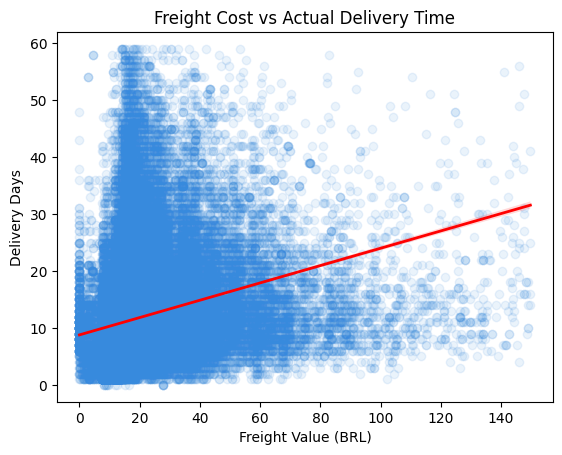

In [41]:
## To make the trend more visible, add a regression line:

import seaborn as sns

# clip extremes first
df2_plot = df2[
    (df2['freight_value'] < 150) &
    (df2['actual_delivery_days'] < 60)
]

# regplot adds the trend line automatically
sns.regplot(
    data=df2_plot,
    x='freight_value',
    y='actual_delivery_days',
    scatter_kws={'alpha': 0.1, 'color': '#378ADD'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('Freight Cost vs Actual Delivery Time')
plt.xlabel('Freight Value (BRL)')
plt.ylabel('Delivery Days')
plt.show()

count    27.000000
mean     18.321567
std       4.912875
min       8.298094
25%      14.999662
50%      18.824895
75%      20.923839
max      28.975610
Name: actual_delivery_days, dtype: float64


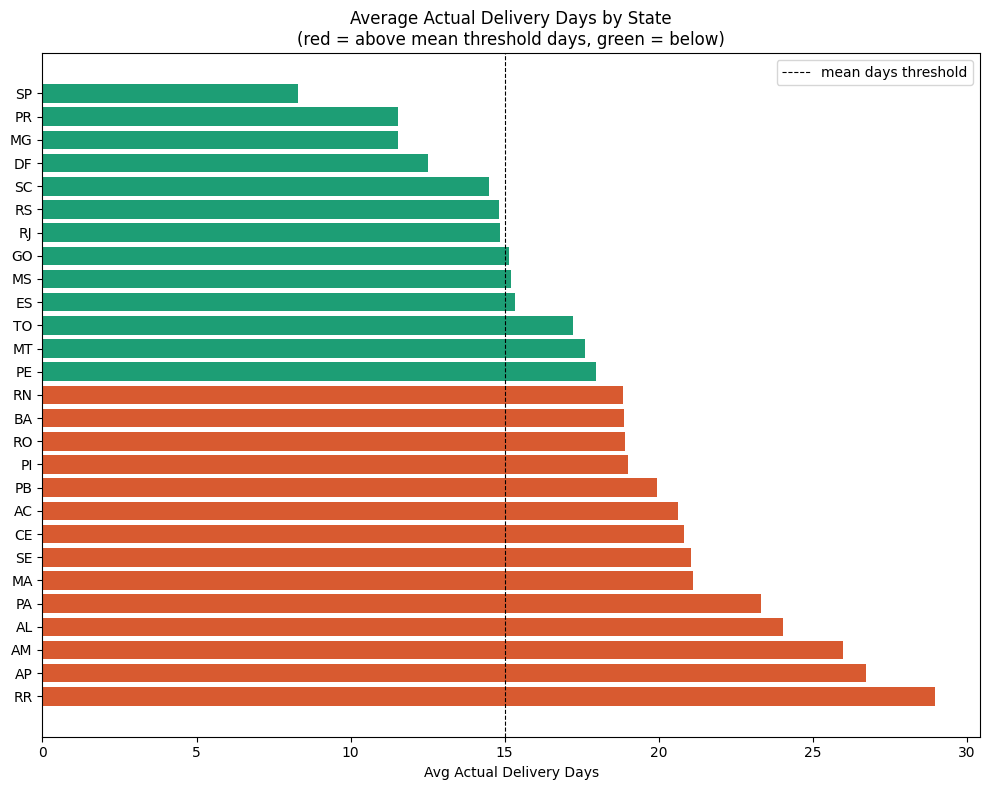

In [47]:
state_actual = (
    df.groupby('customer_state')['actual_delivery_days']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

# Check the actual distribution of state averages first
print(state_actual['actual_delivery_days'].describe())
threshold = state_actual['actual_delivery_days'].mean()

# Same bar chart code but with actual_delivery_days
# This will finally show red vs green properly
colors = ['#D85A30' if x > threshold else '#1D9E75'
          for x in state_actual['actual_delivery_days']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(state_actual['customer_state'],
        state_actual['actual_delivery_days'],
        color=colors)
ax.axvline(x=15, color='black', linewidth=0.8, linestyle='--', label='mean days threshold')
ax.set_title('Average Actual Delivery Days by State\n(red = above mean threshold days, green = below)')
ax.set_xlabel('Avg Actual Delivery Days')
plt.legend()
plt.tight_layout()
plt.show()

SP  →  ~8.3 days

RR  →  ~28.9 days

Gap →  ~20.6 days

"A customer in Roraima waits 3.5x longer for their order than a customer in São Paulo — a 20 day gap driven entirely by geographic remoteness and logistics infrastructure gaps."

"Olist consistently delivers before its promised dates across all 27 states — suggesting estimates are deliberately padded with buffer time as a customer satisfaction strategy. However, actual delivery times tell a different story — customers in remote northern states like RR and AP wait up to 29 days, nearly 3.5x longer than customers in SP (8 days). With a national average of 18 days, Olist should consider setting more realistic regional estimates and investing in northern logistics partnerships to reduce the experience gap."

**Insight 1** — Promise vs Reality: Olist delivers before its promised date across all 27 states, suggesting estimates are deliberately padded — an under-promise, over-deliver strategy.


**Insight 2** — Regional inequality: Customers in remote northern states like RR and AP wait up to 29 days — 3.5x longer than SP customers at 8 days — driven by geographic remoteness and poor logistics infrastructure.


**Insight 3** — Business recommendation: Olist should partner with regional carriers in northern states and either set realistic delivery estimates per region or open fulfillment centers in high-volume remote states.